# 3. Regresión lineal desde cero

**Objetivo.** Construir el primer modelo entrenable sin ocultar el proceso: datos, predicción, pérdida, gradientes y actualización.

Generamos observaciones mediante $y=2x_1-3.4x_2+4.2+\epsilon$ y comprobamos si el entrenamiento recupera los parámetros.

In [1]:
import random
import torch
import matplotlib.pyplot as plt

SEMILLA = 42
random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.set_printoptions(precision=3, sci_mode=False)
print(f"PyTorch {torch.__version__} · semilla {SEMILLA}")

PyTorch 2.14.0 · semilla 42


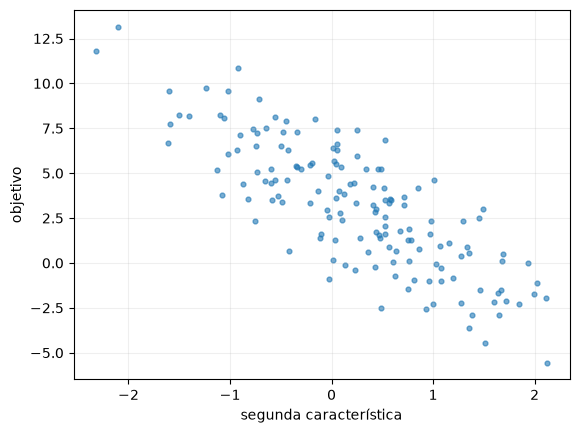

In [2]:
n = 1000
X = torch.randn(n, 2)
w_real = torch.tensor([[2.0], [-3.4]])
b_real = 4.2
y = X @ w_real + b_real + 0.01 * torch.randn(n, 1)

plt.scatter(X[:150, 1], y[:150], s=12, alpha=.6)
plt.xlabel("segunda característica"); plt.ylabel("objetivo"); plt.grid(alpha=.2);

## Modelo y pérdida

La pérdida cuadrática media es $L=\frac{1}{n}\sum_i(\hat y_i-y_i)^2$. Penaliza especialmente los errores grandes y es diferenciable.

In [3]:
w = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def predecir(entradas):
    return entradas @ w + b

def mse(prediccion, objetivo):
    return ((prediccion - objetivo) ** 2).mean()

print("pérdida inicial:", mse(predecir(X), y).item())

pérdida inicial: 28.70421028137207


## Entrenamiento por mini-lotes

Una época recorre una vez todos los ejemplos. Cada mini-lote produce una estimación barata y ruidosa del gradiente.

w aprendido: tensor([ 2.000, -3.399]) · real: tensor([ 2.000, -3.400])
b aprendido: 4.2 · real: 4.2


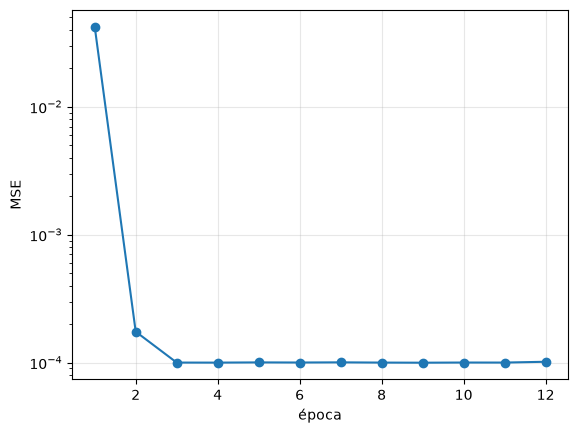

In [4]:
tasa, lote, epocas = 0.05, 32, 12
historia = []
for epoca in range(epocas):
    indices = torch.randperm(n)
    for inicio in range(0, n, lote):
        idx = indices[inicio:inicio + lote]
        perdida = mse(predecir(X[idx]), y[idx])
        perdida.backward()
        with torch.no_grad():
            w -= tasa * w.grad
            b -= tasa * b.grad
        w.grad.zero_(); b.grad.zero_()
    historia.append(mse(predecir(X), y).item())

print("w aprendido:", w.detach().flatten(), "· real:", w_real.flatten())
print("b aprendido:", round(b.item(), 3), "· real:", b_real)
plt.plot(range(1, epocas + 1), historia, marker="o")
plt.xlabel("época"); plt.ylabel("MSE"); plt.yscale("log"); plt.grid(alpha=.3);

## Práctica y diagnóstico

1. Compara tasas `0.001`, `0.05` y `0.5`.
2. Separa el 20 % antes de entrenar y calcula allí el MSE.
3. Aumenta el ruido y observa la diferencia entre parámetros reales y estimados.
4. Explica por qué una pérdida baja en entrenamiento no garantiza generalización.

**Idea clave:** entrenar es repetir: predecir, medir el error, diferenciar y actualizar.